In [1]:
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d, CubicSpline
from classy import Class

plt.rcParams.update({"text.usetex": True, "font.family": "Times new roman"}) # Use latex fonts

colors =  ['#377eb8', '#ff7f00', '#4daf4a',
           '#f781bf', '#a65628', '#984ea3',
           '#999999', '#e41a1c', '#dede00']

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors) # Set the color palette as default

## First define useful functions

In [2]:
def run_CLASS(cosmo_params):

    h = cosmo_params['hlittle']
    As = cosmo_params['A_s']
    Omega_b0 = cosmo_params['OMb']
    Omega_m0 = cosmo_params['OMm']
    ns = cosmo_params['POWER_INDEX']
    Omega_c0 = Omega_m0 - Omega_b0 # CDM portion
    Omega_Lambda = 1. - Omega_m0 # Dark energy portion
    Tcmb0 = 2.728 # CMB temperature in K

    CLASS_params = {}
    CLASS_params['h'] = h
    CLASS_params['Omega_cdm'] = Omega_c0
    CLASS_params['Omega_b'] = Omega_b0
    CLASS_params['n_s'] = ns
    CLASS_params['A_s'] = As
    CLASS_params['T_cmb'] = Tcmb0
    CLASS_params['m_ncdm'] = "0.06" # eV
    CLASS_params['N_ncdm'] = 1
    CLASS_params['N_ur'] = 2.0308
    CLASS_params['output'] = 'tCl,lCl,mTk,mPk'
    CLASS_params['lensing'] = 'yes'
    CLASS_params['z_pk'] = 1050.
    # We need to run CLASS for very large wavenumbers. This is required for computing sigma(M) and the HMF
    CLASS_params['P_k_max_1/Mpc'] = 3000.

    CLASS_OUTPUT = Class()
    CLASS_OUTPUT.set(CLASS_params)
    CLASS_OUTPUT.compute()

    return CLASS_OUTPUT

In [3]:
def Interpolate_transfer(T_CLASS,k_CLASS,k_output):
    # Interpolate the trnasfer function at k_output
    Transfer_interp = interp1d(k_CLASS, T_CLASS, kind='cubic',
                                bounds_error=False,fill_value=0.)
    Transfer = Transfer_interp(k_output)
    # If necessary, extrapolate the transfer function beyond its extent
    # (in a power-law fashion)
    if max(k_output) > max(k_CLASS):
        ind = np.where(k_output > k_CLASS[-1])[0][0] - 1
        if (abs(Transfer[ind]) > 0.) and (abs(Transfer[ind-1]) > 0.):
            slope = np.log(Transfer[ind]/Transfer[ind-1])/np.log(k_output[ind]/k_output[ind-1])
            Transfer[ind:] = Transfer[ind]*pow((k_output[ind:]/k_output[ind]),slope)
    if min(k_output) < min(k_CLASS):
        ind = np.where(k_output < k_CLASS[0])[0][-1] + 1
        if (abs(Transfer[ind]) > 0.) and (abs(Transfer[ind+1]) > 0.):
            slope = np.log(Transfer[ind]/Transfer[ind+1])/np.log(k_output[ind]/k_output[ind+1])
            Transfer[:ind] = Transfer[ind]*pow((k_output[:ind]/k_output[ind]),slope)
    # Return output
    return abs(Transfer)

def compute_T_ZETA_TRANSFER(cosmo_params, k_output, CLASS_OUTPUT):

    Transfer_fnl = CLASS_OUTPUT.get_transfer(0.,'camb')
    Transfer_0 = CLASS_OUTPUT.get_transfer(z=0.)
    k_CLASS = Transfer_0['k (h/Mpc)'][:]*cosmo_params['hlittle'] # 1/Mpc
    transfer_zeta = Transfer_fnl['-T_tot/k2']    # SarahLibanore, fnl

    delta_zeta = Interpolate_transfer(transfer_zeta,k_CLASS,k_output) # SarahLibanore, fnl

    T_ZETA_TRANSFER = list(delta_zeta) # SarahLibanore, fnl

    return T_ZETA_TRANSFER

In [4]:
# SarahLibanore : compute three point functions and derivative wrt Mn for NG corrections to Fcoll 
# The function is computed only at z = 0 
def window(k,M,rhoM):

    R = (3.*M/(4.*np.pi*rhoM))**(1/3.)

    x = (k*R)
    W = 3.0*(np.sin(x) - x*np.cos(x))/(x)**3 

    return W


def der_window(k,M,rhoM):

    R = (3.*M/(4.*np.pi*rhoM))**(1/3.)
    
    x = (k*R)

    dW_dM = (-9*np.sin(x) + 9*x*np.cos(x) + 3*(x**2)*np.sin(x))/((3*M)*(x**3))

    return dW_dM


def Pphi(k, cosmo_params):

    Tphi = 3/5.
    P = Tphi**2 *cosmo_params['A_s'] * pow(k/0.05, cosmo_params['POWER_INDEX']-1) * (2*np.pi**2/k**3) 

    return P


def curlM(k,M,kall,cosmo_params,T_ZETA_TRANSFER):
    
    T_CLASS = interp1d(kall, T_ZETA_TRANSFER, kind='cubic', bounds_error=False,fill_value=0.)

    rho_crit = 2.7754e11 * cosmo_params['hlittle']**2
    rhoM = rho_crit *cosmo_params['OMm']

    Tphi = 3/5.

    curlM = (T_CLASS(k)*k**2/Tphi) * window(k,M,rhoM)

    return curlM


def der_curlM(k,M,kall,cosmo_params,T_ZETA_TRANSFER):
    
    T_CLASS = interp1d(kall, T_ZETA_TRANSFER, kind='cubic', bounds_error=False,fill_value=0.)

    rho_crit = 2.7754e11 * cosmo_params['hlittle']**2
    rhoM = rho_crit * cosmo_params['OMm']
    Tphi = 3/5.

    dcurlM = (T_CLASS(k)*k**2/Tphi) * der_window(k,M,rhoM)

    return dcurlM


def FM(kall,k_1,Mm,k_class,cosmo_params,T_ZETA_TRANSFER):

    mu = np.linspace(-0.995, 0.995, 128) # cos theta

    Mm = Mm[None,None, None,:]
    k_1 = k_1[:,None, None,None]
    k_2 = kall[None,:, None,None]
    mu_val = mu[None,None,:,None]

    integrate_k2 = 1
    integrate_mu = 2

    Pphi_1 = Pphi(k_1,cosmo_params)
    Pphi_2 = Pphi(k_2,cosmo_params)

    k_12 = np.sqrt(pow(k_1,2)+pow(k_2,2) + 2*k_1*k_2*mu_val)

    curlM_2 = curlM(k_2,Mm,k_class,cosmo_params,T_ZETA_TRANSFER) 
    curlM_12 = curlM(k_12,Mm,k_class,cosmo_params,T_ZETA_TRANSFER) 

    der_curlM_2 = der_curlM(k_2,Mm,k_class,cosmo_params,T_ZETA_TRANSFER) 
    der_curlM_12 = der_curlM(k_12,Mm,k_class,cosmo_params,T_ZETA_TRANSFER) 

    integrand = k_2**2 * curlM_2 * curlM_12 * (Pphi_1 * Pphi_2 )
    
    integral_dk2 = np.trapz(integrand, mu, axis = integrate_mu)
    Fm = np.trapz(integral_dk2, kall, axis = integrate_k2)

    Fm *= 6. * cosmo_params['F_NL'] / (8*np.pi**4.) 

    integrand_dn2 = k_2**2 * (Pphi_1 * Pphi_2 ) * (der_curlM_2 * curlM_12 + curlM_2 * der_curlM_12)
    
    integral_dk2_dn2 = np.trapz(integrand_dn2, mu, axis = integrate_mu)
    dFm_dn2 = np.trapz(integral_dk2_dn2, kall, axis = integrate_k2)
    
    dFm_dn2 *= 6. * cosmo_params['F_NL'] / (8*np.pi**4.) 


    return Fm, dFm_dn2


def tpf(log10_mass_array,cosmo_params,T_ZETA_TRANSFER,LOG_K_ARR_FOR_TRANSFERS):

    print('Computing three point functions to estimate the Fcoll NG corrections...')

    MassVector = pow(10, log10_mass_array)

    kall_full = pow(10.,np.array(LOG_K_ARR_FOR_TRANSFERS)) # 1/Mpc
    kall = np.asarray(kall_full[[kall_full > cosmo_params['KCUT_FNL']][0]])
    
    k_1 = kall[:,None,None]

    Mn = MassVector[None,:,None]

    curlM_1 = curlM(k_1,Mn,kall_full,cosmo_params,T_ZETA_TRANSFER) 

    Fmv, dFm_dn2v = FM(kall,kall, MassVector,kall_full,cosmo_params,T_ZETA_TRANSFER)
    Fm = Fmv[:,None,:]
    dFm_dn2 = dFm_dn2v[:,None,:]
    der_curlM_1 = der_curlM(k_1,Mn,kall_full,cosmo_params,T_ZETA_TRANSFER) 

    integrand = k_1** 2 * curlM_1 * Fm

    ddd = np.trapz(integrand,kall,axis=0)

    integrand_dnm2 = k_1** 2 * der_curlM_1 * Fm
    integrand_dmn2 = k_1** 2 * curlM_1 * dFm_dn2
    integrand_dn3 = k_1** 2 * (der_curlM_1 * Fm + curlM_1 * dFm_dn2)

    der_dnm2 = np.trapz(integrand_dnm2,kall,axis=0)
    der_dmn2 = np.trapz(integrand_dmn2,kall,axis=0)
    der_dn3 = np.trapz(integrand_dn3,kall,axis=0)

    return ddd, der_dn3, der_dmn2, der_dnm2

In [5]:
def three_point_interpolations(Mn, Mm, tp):
    """
    2D linear interpolation of the three-point function in log10(Mn), log10(Mm).
    """

    # Convert to log10
    log_Mn = np.log10(Mn)
    log_Mm = np.log10(Mm)

    logM_arr = list(log10_M_array)
    npts = len(log10_M_array)

    # Bounds checking for Mn
    if log_Mn < logM_arr[0]:
        raise ValueError(
            f"Attempted to compute three point function for Mn={Mn:e}, "
            f"but minimum M in the interpolation table is {10**logM_arr[0]:e}"
        )
    elif log_Mn > logM_arr[npts - 1]:
        raise ValueError(
            f"Attempted to compute three point function for Mn={Mn:e}, "
            f"but maximum M in the interpolation table is {10**logM_arr[npts - 1]:e}"
        )

    # Bounds checking for Mm
    if log_Mm < logM_arr[0]:
        raise ValueError(
            f"Attempted to compute three point function for Mm={Mm:e}, "
            f"but minimum M in the interpolation table is {10**logM_arr[0]:e}"
        )
    elif log_Mm > logM_arr[npts - 1]:
        raise ValueError(
            f"Attempted to compute three point function for Mm={Mm:e}, "
            f"but maximum M in the interpolation table is {10**logM_arr[npts - 1]:e}"
        )

    # Grid spacing (assumed uniform)
    dlog10_M = logM_arr[1] - logM_arr[0]

    # Find lower indices
    Mn_ind = int(np.floor((log_Mn - logM_arr[0]) / dlog10_M))
    Mm_ind = int(np.floor((log_Mm - logM_arr[0]) / dlog10_M))

    # Clamp indices to stay within bounds for +1 access
    if Mn_ind == npts - 1:
        Mn_ind -= 1
    if Mm_ind == npts - 1:
        Mm_ind -= 1

    # Neighbouring grid points
    log_Mn1 = logM_arr[Mn_ind]
    log_Mn2 = logM_arr[Mn_ind + 1]
    log_Mm1 = logM_arr[Mm_ind]
    log_Mm2 = logM_arr[Mm_ind + 1]

    dnn = tp[Mm_ind     + npts * Mn_ind]
    dnm = tp[Mm_ind     + npts * (Mn_ind + 1)]
    dmn = tp[Mm_ind + 1 + npts * Mn_ind]
    dmm = tp[Mm_ind + 1 + npts * (Mn_ind + 1)]

    # 2D linear interpolation
    dd1 = (dmn * (log_Mm - log_Mm1) + dnn * (log_Mm2 - log_Mm)) / (log_Mm2 - log_Mm1)
    dd2 = (dmm * (log_Mm - log_Mm1) + dnm * (log_Mm2 - log_Mm)) / (log_Mm2 - log_Mm1)

    ddd = (dd2 * (log_Mn - log_Mn1) + dd1 * (log_Mn2 - log_Mn)) / (log_Mn2 - log_Mn1)

    return ddd


In [8]:
def sigma_Mz(Mh,z,cosmo_params,CLASS_OUTPUT):

    rho_crit = 2.7754e11 * cosmo_params['hlittle']**2
    rhoM = rho_crit * (CLASS_OUTPUT.Omega0_m()-CLASS_OUTPUT.Omega_nu)

    R = pow(Mh*3./4./np.pi/cosmo_params['OMm']/rho_crit,1./3.)

    sigma = CLASS_OUTPUT.sigma(R,z)

    return sigma

def sigma_linear_2D_interpolation(M, z,use_SIGMA_MZ):
    """
    Bilinear interpolation of sigma(M, z)
    """

    # Convert to log10(M)
    log_M = np.log10(M)

    z_arr = Z_ARRAY_FOR_SIGMA
    logM_arr = list(log10_M_array)

    SIGMA_M_NPTS = len(logM_arr)
    SIGMA_Z_NPTS = len(z_arr)
    # Bounds checking
    if log_M < logM_arr[0]:
        raise ValueError(
            f"Attempted to compute sigma(M,z) for M={M:e}, "
            f"but minimum M in the interpolation table is {10**logM_arr[0]:e}"
        )
    elif log_M > logM_arr[SIGMA_M_NPTS - 1]:
        raise ValueError(
            f"Attempted to compute sigma(M,z) for M={M:e}, "
            f"but maximum M in the interpolation table is {10**logM_arr[SIGMA_M_NPTS - 1]:e}"
        )
    elif z < z_arr[0]:
        raise ValueError(
            f"Attempted to compute sigma(M,z) for z={z:.6f}, "
            f"but minimum z in the interpolation table is {z_arr[0]:.6f}"
        )
    elif z > z_arr[SIGMA_Z_NPTS - 1]:
        raise ValueError(
            f"Attempted to compute sigma(M,z) for z={z:.6f}, "
            f"but maximum z in the interpolation table is {z_arr[SIGMA_Z_NPTS - 1]:.6f}"
        )

    # Grid spacings
    dlog10_M = logM_arr[1] - logM_arr[0]
    dz = z_arr[1] - z_arr[0]

    # Lower indices
    M_ind = int(np.floor((log_M - logM_arr[0]) / dlog10_M))
    z_ind = int(np.floor((z - z_arr[0]) / dz))

    # Safety: avoid out-of-bounds for +1
    if M_ind == SIGMA_M_NPTS - 1:
        M_ind -= 1
    if z_ind == SIGMA_Z_NPTS - 1:
        z_ind -= 1

    # Neighbouring grid points
    z1 = z_arr[z_ind]
    z2 = z_arr[z_ind + 1]
    log_M1 = logM_arr[M_ind]
    log_M2 = logM_arr[M_ind + 1]

    sig = use_SIGMA_MZ

    sigma11 = sig[z_ind     + SIGMA_Z_NPTS * M_ind]
    sigma12 = sig[z_ind     + SIGMA_Z_NPTS * (M_ind + 1)]
    sigma21 = sig[z_ind + 1 + SIGMA_Z_NPTS * M_ind]
    sigma22 = sig[z_ind + 1 + SIGMA_Z_NPTS * (M_ind + 1)]

    # Bilinear interpolation
    sigma1 = (sigma21 * (z - z1) + sigma11 * (z2 - z)) / (z2 - z1)
    sigma2 = (sigma22 * (z - z1) + sigma12 * (z2 - z)) / (z2 - z1)

    sigma = (
        sigma2 * (log_M - log_M1)
        + sigma1 * (log_M2 - log_M)
    ) / (log_M2 - log_M1)

    return sigma


def sigma_numerical_derivative(M, z,use_sig) :

  dlog10_M = 0.1;
  sigma = sigma_linear_2D_interpolation(M,z,use_sig);
  dsigma_dlog10_M = (sigma_linear_2D_interpolation(M*pow(10.,dlog10_M),z,use_sig) - sigma)/dlog10_M; 
  dsigma_dM = 1./(np.log(10.)*M)*dsigma_dlog10_M;
  
  return dsigma_dM;


def sigma_sq_numerical_derivative(M, z, use_sig) :

  dlog10_M = 0.1;
  sigma = sigma_linear_2D_interpolation(M,z,use_sig);
  dsigma_2_dlog10_M = (sigma_linear_2D_interpolation(M*pow(10.,dlog10_M),z,use_sig) - sigma)/dlog10_M; #// dsigma/dlog_10(M)
#  // Chain rule: dsigma^2/dM = 2*sigma*dsigma/dM = 2*sigma*dsigma/dlog_10(M) * dlog_10(M)/dM = (2*sigma)/(ln(10)*M)*dsigma/dlog_10(M)
  dsigma_sq_dM = 2.*sigma/(np.log(10.)*M)*dsigma_2_dlog10_M;
  return dsigma_sq_dM;


In [9]:
def dicke(z,use_LOG_SIGF):

    LOG_SIGF_use = use_LOG_SIGF
    if z == 0.:
        return 1. 
    log_z_arr = np.array(LOG_Z_ARR, dtype=float)
    log_SIGF_arr = np.array(LOG_SIGF_use, dtype=float)

    _CLASS_growth_spline = CubicSpline(
        log_z_arr,
        log_SIGF_arr,
        bc_type='natural'
    )

    # --------------------------------------------------
    # Evaluate spline
    # --------------------------------------------------
    if _CLASS_growth_spline is None:
        raise RuntimeError(
            "CLASS_GROWTH_FACTOR called before spline initialization (flag=1)"
        )

    log10_z = np.log10(z)

    if log10_z > LOG_Z_ARR[len(LOG_Z_ARR) - 1]:
        raise ValueError(f"Called CLASS_GROWTH_FACTOR with z={z}")

    ans = _CLASS_growth_spline(log10_z)
    
    return 10.0**ans

In [10]:
def dNdM_unconditional(M, z, growthf, cosmo_params, USE_SIG):

    delta_c = 1.686

    #/* Non-Gaussian correction */
    ratio_CGF = 1.0;   #/* default: Gaussian (no PNG correction) */

    #    NON GAUSSIAN CORRECTION
    if (cosmo_params['F_NL'] != 0.):

    #    /* sigma(M) at z=0  */

        sigmaM   = sigma_linear_2D_interpolation(M, 0., USE_SIG)      # sigma_0(M)
        dsigmadm = sigma_sq_numerical_derivative(M, 0., USE_SIG)      # dS_0/dM

        S       = sigmaM * sigmaM;  #   /* variance sigma^2(M)          */
        delta_c = delta_c / growthf;  #        /* barrier at z         */
        mu3     = three_point_interpolations(M, M, THREEPOINT_MnMm);#   /* <delta^3>, ~ f_NL */
        dmu3_dM = three_point_interpolations(M, M, THREEPOINT_DER_Mn3); #// diagonal in the matrix

        sigma3 = sigmaM * sigmaM * sigmaM;

        SHETH_a = 0.707
        barrier  = np.sqrt(SHETH_a) * 1.686 / growthf                 # divide by D once
        nu       = barrier / sigmaM
        kappa3  = mu3 / (sigmaM * sigmaM * sigmaM);
        H3nu    = nu * nu * nu - 3.0 * nu;

        ratio_dk_dnu = 0.0;
        if (abs(dsigmadm) > 0.0 and abs(nu) > 1e-10):
            ratio_dk_dnu = ( 3.0*kappa3 - 2.0*S*dmu3_dM/(sigma3*dsigmadm) ) / nu;

        if (abs(mu3) >= 1.0e-10 * S * S):

            #// 2009.01245 appendix 
            nu2  = nu  * nu;
            nu3  = nu2 * nu;
            nu4  = nu3 * nu;
            nu5  = nu4 * nu;
            nu6  = nu5 * nu;
            nu7  = nu6 * nu;
            nu8  = nu7 * nu;
            nu9  = nu8 * nu;

            #/* Hermite polynomials */
            H2nu = nu2 - 1.0;
            H5nu = nu5 - 10.0*nu3 + 15.0*nu;
            H6nu = nu6 - 15.0*nu4 + 45.0*nu2 - 15.0;
            H8nu = nu8 - 28.0*nu6 + 210.0*nu4 - 420.0*nu2 + 105.0;
            H9nu = nu9 - 36.0*nu7 + 378.0*nu5 - 1260.0*nu3 + 945.0*nu;

            kappa3_sq = kappa3 * kappa3;
            kappa3_cu = kappa3_sq * kappa3;

            #/* First order: F1'/F0'  (eq. 38) */
            ratio_1 = kappa3 * H3nu / 6.0 - H2nu / 6. * ratio_dk_dnu ;

            #/* Second order: F2'/F0'  (eq. 39) */
            ratio_2 = kappa3_sq * H6nu / 72.0 - kappa3 * H5nu / 36.0 * ratio_dk_dnu;

            #/* Third order: F3'/F0'  (eq. 40) */
            ratio_3 = kappa3_cu * H9nu / 1296.0 - kappa3_sq * H8nu / 432.0 * ratio_dk_dnu;

            ratio_CGF = 1. + ratio_1 + ratio_2 + ratio_3; #// Non-Gauss correction

    else:
        ratio_CGF = 1. 

    return ratio_CGF



In [11]:
def dNdM_conditional(growthf, M1, M2,
                    delta1, delta2,
                    sigma2, z, cosmo_params, USE_SIG):

    # sigma(M_s) and d sigma^2 / dM 
    sigma1   = sigma_linear_2D_interpolation(M1, z=0.,use_SIGMA_MZ= USE_SIG) ;
    dsigmadm = sigma_sq_numerical_derivative(M1, z=0.,use_sig=USE_SIG ) ;
 
    # Square the rms values to get variances. */
    sigma1 = sigma1 * sigma1;
    sigma2 = sigma2 * sigma2;
 
    den_MIN = 1.0e-6;
 
    # Growth-factor-divided thresholds. */
    delta_c = delta1 / growthf; # barrier at z 
    delta_l = delta2 / growthf; # overdensity at z = 0 

    #/* Effective barrier and variance increments (growth-factor-divided).*/
    DD = delta_c - delta_l;
    SS = sigma1 - sigma2;
 
    #/* Scales not hierarchically separated or large-scale variance
    # * too small: the walk has no room to make a first crossing. */
    if (SS < den_MIN or sigma2 < den_MIN):
        return 0.0;
 
    #// GAUSSIAN DFCOLL/DM
    dfcoll_Gauss = DD * np.exp(-pow(DD,2) / (2.0 * SS))\
        / pow(SS,1.5) / np.sqrt(np.pi*2);

    # * Non-Gaussian conditional rate 
    if (cosmo_params['F_NL'] != 0. and DD >= den_MIN):
        #/* Four bispectrum-derived cumulants.
        # *   mu_sss = <delta_s^3>          (small scale)
        # *   mu_lll = <delta_l^3>          (large scale)
        # *   mu_ssl = <delta_s^2 delta_l>      
        # *   mu_sll = <delta_s delta_l^2>             
        # */
        mu_sss = three_point_interpolations(M1, M1, THREEPOINT_MnMm);
        mu_lll = three_point_interpolations(M2, M2, THREEPOINT_MnMm);
        mu_sll = three_point_interpolations(M1, M2, THREEPOINT_MnMm);
        mu_ssl = three_point_interpolations(M2, M1, THREEPOINT_MnMm);
 
    #/* Eq 5 in 1304.8049 or Eq 49 in 1206.3305*/
        x = SS / (DD * DD);

        #// derivatives of the three point functions 
        dmu_sss_dMmin = three_point_interpolations(M1,M1,THREEPOINT_DER_Mn3); #// diagonal in the matrix
        dmu_sll_dMin = three_point_interpolations(M1,M2,THREEPOINT_DER_MnMm2); #// upper triangular
        dmu_ssl_dMin =  three_point_interpolations(M2,M1,THREEPOINT_DER_MmMn2); #// lower triangular
        
        A_v = (
            mu_sss
            - mu_lll
            + 3.0 * mu_sll
            - 3.0 * mu_ssl
        );
        dA_dMmin = (
            dmu_sss_dMmin
            + 3.0 * dmu_sll_dMin
            - 3.0 * dmu_ssl_dMin
        );

        B_v =  (mu_lll + mu_ssl - 2.0 * mu_sll);
        dB_dMmin = (dmu_ssl_dMin - 2.0 * dmu_sll_dMin);

        C_v = mu_sll - mu_lll;
        dC_dMmin = dmu_sll_dMin;
        
        alpha = -(1.0 / (DD * DD)) * (
            1.0 / (1.0 - x) + 2.5 / x - 0.5 / (x * x)
        );

        beta = (1.0 / (2.0 * DD * DD)) * (1.0 / (x * x) - 3.0 / x);
        gamma = (1.0 / (2.0 * DD * DD)) * (1.0 / (x * x) - 1.0 / x);
        chi = (1.0 / (3.0 * DD)) * (1.0 / x - 1.0);

        y = delta_c * DD / sigma2;

        psi = (delta_c - DD) / sigma2 - (2.0 * DD / sigma2) / (np.exp(2.0*y)-1.);

        w = (
            SS / (sigma2 * DD) / sigma2
            * (
                pow(delta_l,2)
                - sigma2
                - (4.0 * delta_c * DD)
                / (np.exp(2.0 * y) - 1.0)
            )
        );

        dfcoll_dM_NG = (
                (dA_dMmin + alpha * A_v * dsigmadm) * chi
                + (dB_dMmin + beta * B_v * dsigmadm) * psi
                + (dC_dMmin + gamma * C_v * dsigmadm) * w
            ) ;
            
        dfcoll = - (dsigmadm + dfcoll_dM_NG) * dfcoll_Gauss; #// non-Gaus corrected dfcoll

        #/* Only fall back if the TOTAL result is unphysical */
        if (dfcoll < 0.0) :
            dfcoll = -dsigmadm * dfcoll_Gauss;
    else:
    #/* Gaussian first-crossing rate (PNG off). */
        dfcoll = -dsigmadm * dfcoll_Gauss;
 
    return dfcoll;


## Define the parameters used in the run 

In [13]:
# don't change this array 

LOG_K_ARR_FOR_TRANSFERS = [-5.15144838, -5.0514484 , -4.95144828, -4.85144824, -4.75144831,
                                         -4.65144846, -4.55144842, -4.45144844, -4.35144836, -4.2514484 ,
                                         -4.15144838, -4.0514484 , -3.95144828, -3.85144824, -3.75144831,
                                         -3.65144846, -3.55144842, -3.45144844, -3.35144836, -3.2514484 ,
                                         -3.15144838, -3.0514484 , -2.95144828, -2.85144824, -2.75144831,
                                         -2.65144846, -2.55144842, -2.45144844, -2.35144836, -2.2514484 ,
                                         -2.15144838, -2.0514484 , -1.95144828, -1.85144855, -1.75145051,
                                         -1.65167858, -1.55757323, -1.49148227, -1.44915893, -1.41712202,
                                         -1.39038991, -1.36686022, -1.34546231, -1.3255776 , -1.30681547,
                                         -1.28891354, -1.27168632, -1.25499794, -1.23874561, -1.22284979,
                                         -1.20724751, -1.19188819, -1.17673058, -1.1617405 , -1.14688964,
                                         -1.13215425, -1.11751423, -1.1029525 , -1.08845468, -1.07400858,
                                         -1.05960376, -1.04523159, -1.0308847 , -1.01655703, -1.00224362,
                                         -0.98794056, -0.97364449, -0.95935297, -0.9450646 , -0.93077752,
                                         -0.91649165, -0.90220562, -0.88792009, -0.87363446, -0.85934868,
                                         -0.84506291, -0.83077684, -0.81649043, -0.80220246, -0.78791232,
                                         -0.7736182 , -0.75931799, -0.74500867, -0.73068674, -0.71634763,
                                         -0.70198555, -0.6875937 , -0.67316396, -0.65868698, -0.64415096,
                                         -0.6295428 , -0.61484684, -0.60004451, -0.58511402, -0.57002998,
                                         -0.5547616 , -0.53927245, -0.5235185 , -0.50744591, -0.49098831,
                                         -0.47406185, -0.45656015, -0.43834405, -0.41922757, -0.39895473,
                                         -0.3771609 , -0.35330423, -0.32653792, -0.29545819, -0.25758495,
                                         -0.20836373, -0.14039666, -0.05026523,  0.04900858,  0.1489976 ,
                                         0.24899768,  0.34899762,  0.44899771,  0.54899762,  0.64899771,
                                         0.7489977 ,  0.84899769,  0.94899765,  1.04899772,  1.1489976 ,
                                         1.24899768,  1.34899762,  1.44899771,  1.54899762,  1.64899771,
                                         1.7489977 ,  1.84899769,  1.94899765,  2.04899772,  2.1489976 ,
                                         2.24899768,  2.34899762,  2.44899771,  2.54899762,  2.64899771,
                                         2.7489977 ,  2.84899769,  2.94899765,  3.04899772]

LOG_Z_ARR = [0.69897, 0.73291816, 0.76686631, 0.80081447, 0.83476262,
                           0.86871078, 0.90265893, 0.93660709, 0.97055524, 1.0045034,
                           1.03845155, 1.07239971, 1.10634786, 1.14029602, 1.17424417,
                           1.20819233, 1.24214048, 1.27608864, 1.31003679, 1.34398495,
                           1.3779331 , 1.41188126, 1.44582941, 1.47977756, 1.51372572,
                           1.54767387, 1.58162203, 1.61557018, 1.64951834, 1.68346649,
                           1.71741465, 1.7513628 , 1.78531096, 1.81925911, 1.85320727,
                           1.88715542, 1.92110358, 1.95505173, 1.98899989, 2.02294804,
                           2.0568962 , 2.09084435, 2.12479251, 2.15874066, 2.19268882,
                           2.22663697, 2.26058512, 2.29453328, 2.32848143, 2.36242959,
                           2.39637774, 2.4303259 , 2.46427405, 2.49822221, 2.53217036,
                           2.56611852, 2.60006667, 2.63401483, 2.66796298, 2.70191114,
                           2.73585929, 2.76980745, 2.8037556 , 2.83770376, 2.87165191,
                           2.90560007, 2.93954822, 2.97349638, 3.00744453, 3.04139269]

log10_M_array = np.linspace(4.,20.,300)
use_M = np.logspace(5,19)

Z_ARRAY_FOR_SIGMA = list(np.linspace(0,50,101))


# !!! Here you can change the parameters for your plots

In [14]:
kcut_fnl = 1e-2
fnl = 100.

# set same fiducial cosmology as your 21cmFirstCLASS runs
cosmo_params = lambda fnl, kcut_fnl: {"hlittle": 0.6736, # hubble parameter
                "OMb": 0.0493, # baryon density
                "OMm": 0.3153, # matter (CDM+baryon) density
                "A_s": 2.1e-9, # amplitude of the primordial fluctuations
                "POWER_INDEX": 0.9649, # spectral index of the primordial spectrum
                "tau_reio": 0.0544, # optical depth to reionization
                "F_NL":fnl, # to test matching with old case
                "KCUT_FNL": kcut_fnl
                }

Ml = 1e16 # this is the environmental M (Mm in our text) -- you can check if and how things change varying this

delta_c = 1.686
zfn = 8.  # redshift at which your HMF plots are produced

cosmo_params_Gauss = cosmo_params(0., kcut_fnl)
cosmo_params_NG = cosmo_params(fnl, kcut_fnl)

## Run CLASS

In [15]:
CLASS_OUTPUT = run_CLASS(cosmo_params_Gauss)
k_output = pow(10.,np.array(LOG_K_ARR_FOR_TRANSFERS)) # 1/Mpc
T_ZETA_TRANSFER = compute_T_ZETA_TRANSFER(cosmo_params_Gauss, k_output,CLASS_OUTPUT)
LOG_SIGF = list(
    np.log10(np.array([CLASS_OUTPUT.scale_independent_growth_factor(pow(10.,log_z)) for log_z in LOG_Z_ARR])))

SIGMA_MZ_matr = np.zeros((len(Z_ARRAY_FOR_SIGMA), len(log10_M_array)))
for z_ind, z in enumerate(Z_ARRAY_FOR_SIGMA):
    for M_ind, M in enumerate(pow(10.,log10_M_array)):
        SIGMA_MZ_matr[z_ind,M_ind] = sigma_Mz(M,z,cosmo_params_Gauss,CLASS_OUTPUT)

SIGMA_MZ = list(SIGMA_MZ_matr.T.flatten())


## Compute the Mn-Mm matrix

In [16]:
temp = tpf(log10_M_array,cosmo_params_NG,T_ZETA_TRANSFER, LOG_K_ARR_FOR_TRANSFERS)

THREEPOINT_MnMm_mat = temp[0]
THREEPOINT_DER_Mn3_mat = temp[1]
THREEPOINT_DER_MmMn2_mat = temp[2]
THREEPOINT_DER_MnMm2_mat = temp[3]

THREEPOINT_DER_Mn3 = list(THREEPOINT_DER_Mn3_mat.flatten())
THREEPOINT_DER_MmMn2 = list(THREEPOINT_DER_MmMn2_mat.flatten())
THREEPOINT_DER_MnMm2 = list(THREEPOINT_DER_MnMm2_mat.flatten())

THREEPOINT_MnMm = list(THREEPOINT_MnMm_mat.flatten())

Computing three point functions to estimate the Fcoll NG corrections...


## Plots relevant for the unconditional mass function

In [17]:
# plot kappa3 and its derivative

use_k3 = np.zeros(len(use_M))
use_der_k3 = np.zeros(len(use_M))
use_sigma = np.zeros(len(use_M))
use_dsigmadM = np.zeros(len(use_M))

for i in range(len(use_M)):

    dn3_i = three_point_interpolations(use_M[i],use_M[i],THREEPOINT_MnMm)

    der_dn3_i = three_point_interpolations(use_M[i],use_M[i],THREEPOINT_DER_Mn3)

    use_sigma[i] = sigma_Mz(use_M[i],0.,cosmo_params_NG,CLASS_OUTPUT)
    use_dsigmadM[i] = sigma_numerical_derivative(use_M[i],0.,SIGMA_MZ)

    use_k3[i] = dn3_i / use_sigma[i]**3
    use_der_k3[i] = (der_dn3_i - 3.*dn3_i * use_dsigmadM[i] / use_sigma[i])/use_sigma[i]**3


(100000000.0, 10000000000000.0)

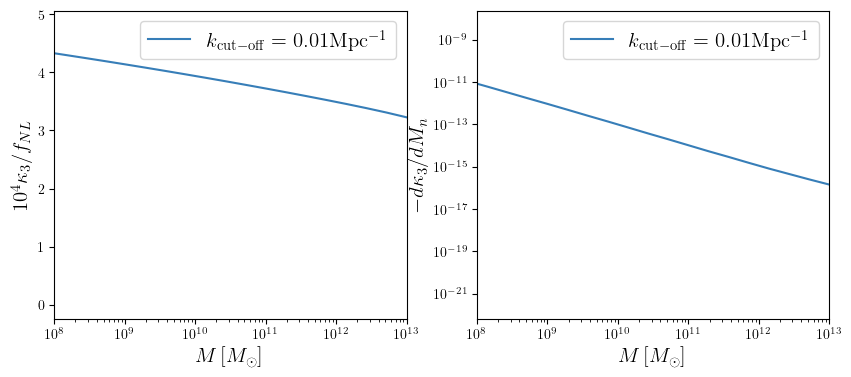

In [18]:
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.semilogx(use_M,1e4*use_k3/cosmo_params_NG['F_NL'],label=r'$k_{\rm cut-off}=%g{\rm Mpc^{-1}}$'%kcut_fnl)
plt.xlabel(r'$M\,[M_\odot]$',fontsize=15)
plt.ylabel(r'$10^4\kappa_3/f_{NL}$',fontsize=15)
plt.legend(fontsize=15)
plt.xlim(1e8,1e13)

plt.subplot(122)
plt.loglog(use_M,-use_der_k3,label=r'$k_{\rm cut-off}=%g{\rm Mpc^{-1}}$'%kcut_fnl)
plt.xlabel(r'$M\,[M_\odot]$',fontsize=15)
plt.ylabel(r'$-d\kappa_3/dM_{n}$',fontsize=15)
plt.legend(fontsize=15)
plt.xlim(1e8,1e13)

In [19]:
# plot the unconditional mass function

gauss_uncond = np.zeros(len(use_M))
ng_uncond = np.zeros(len(use_M))

for i in range(len(use_M)):

    gauss_uncond[i] = dNdM_unconditional((use_M[i]),  z=zfn, growthf=dicke(zfn,LOG_SIGF), cosmo_params=cosmo_params_Gauss, USE_SIG=SIGMA_MZ)

    ng_uncond[i] = dNdM_unconditional((use_M[i]),  z=zfn, growthf=dicke(zfn,LOG_SIGF), cosmo_params=cosmo_params_NG, USE_SIG=SIGMA_MZ)


Text(0.5, 0, '$M$')

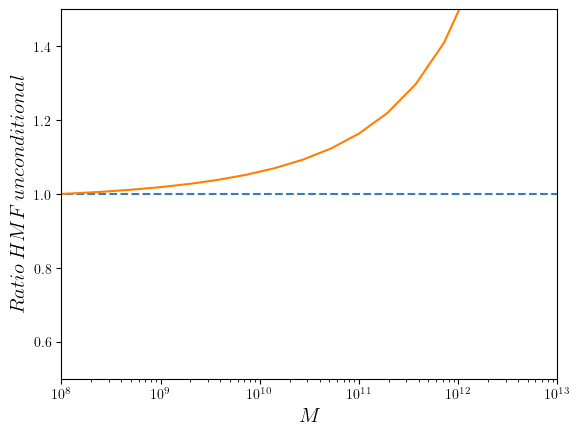

In [20]:
fig, ax = plt.subplots(1,1,)

ax.semilogx(use_M,np.ones(len(use_M)),ls='--')
ax.semilogx(use_M, ng_uncond / gauss_uncond )

ax.set_ylim(0.5,1.5)
ax.set_xlim(1e8,1e13)

ax.set_ylabel(r'$Ratio\,HMF\,unconditional$',fontsize=15)
ax.set_xlabel(r'$M$',fontsize=15)

## Plots relevant for the conditional mass function

In [21]:
# plot the three point function and its derivative

x = np.zeros(len(use_M))
dn3 = np.zeros(len(use_M))
dnm2 = np.zeros(len(use_M))
dmn2 = np.zeros(len(use_M))

use_der_dn3 = np.zeros(len(use_M))
use_der_dnm2 = np.zeros(len(use_M))
use_der_dmn2 = np.zeros(len(use_M))

for i in range(len(use_M)):
    x[i] = sigma_Mz(use_M[i],0.,cosmo_params_NG,CLASS_OUTPUT)**2

    dn3[i] = three_point_interpolations(use_M[i], use_M[i], THREEPOINT_MnMm) / cosmo_params_NG['F_NL'] / 1e-4 
    dnm2[i] = three_point_interpolations(use_M[i], Ml, THREEPOINT_MnMm) / cosmo_params_NG['F_NL'] / 1e-4
    dmn2[i] = three_point_interpolations(Ml, use_M[i], THREEPOINT_MnMm) / cosmo_params_NG['F_NL'] / 1e-4

    use_der_dn3[i] = three_point_interpolations(use_M[i], use_M[i], THREEPOINT_DER_Mn3) / cosmo_params_NG['F_NL'] / 1e-4 
    use_der_dnm2[i] = three_point_interpolations(use_M[i], Ml, THREEPOINT_DER_MnMm2) / cosmo_params_NG['F_NL'] / 1e-4
    use_der_dmn2[i] = three_point_interpolations(use_M[i], Ml, THREEPOINT_DER_MmMn2) / cosmo_params_NG['F_NL'] / 1e-4



/tmp/ipykernel_3017120/298998184.py:21: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,4)


Text(0.5, 1.0, '$\\log_{10}M_n=16$')

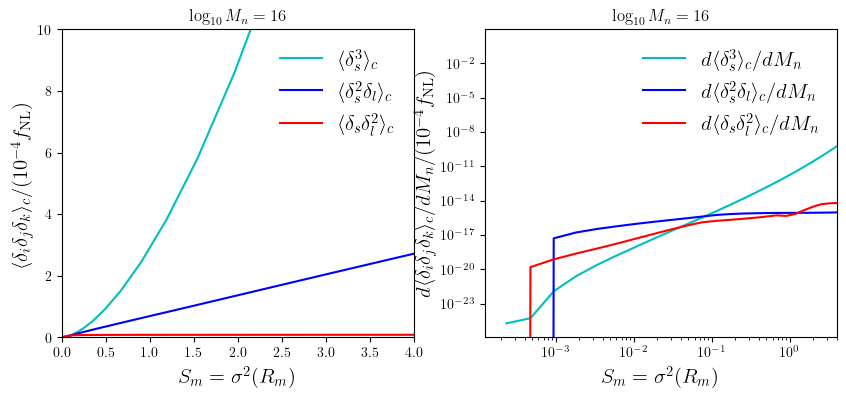

In [22]:
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.plot(x,dn3,color='c',label=r'$\langle\delta_s^3\rangle_c$')
plt.plot(x,dmn2,'b',label=r'$\langle\delta_s^2\delta_l\rangle_c$')
plt.plot(x,dnm2,'r',label=r'$\langle\delta_s\delta_l^2\rangle_c$')


plt.legend(fontsize=15,frameon=False)
plt.xlim(0,4)
plt.xlabel(r'$S_m=\sigma^2(R_m)$',fontsize=15)
plt.ylim(0,10)
plt.ylabel(r'$\langle \delta_i\delta_j\delta_k\rangle_c / (10^{-4}f_{\rm NL})$',fontsize=15)
plt.title(r'$\log_{10}M_n=%g$'%np.log10(Ml))

plt.subplot(122)
plt.loglog(x,-use_der_dn3/ cosmo_params_NG['F_NL'] / 1e-4 ,color='c',label=r'$d\langle\delta_s^3\rangle_c/dM_n$')
plt.loglog(x,-use_der_dmn2/ cosmo_params_NG['F_NL'] / 1e-4 ,'b',label=r'$d\langle\delta_s^2\delta_l\rangle_c/dM_n$')
plt.loglog(x,-use_der_dnm2/ cosmo_params_NG['F_NL'] / 1e-4 ,'r',label=r'$d\langle\delta_s\delta_l^2\rangle_c/dM_n$')

plt.legend(fontsize=15,frameon=False)
plt.xlim(0,4)
plt.xlabel(r'$S_m=\sigma^2(R_m)$',fontsize=15)
plt.ylabel(r'$d\langle \delta_i\delta_j\delta_k\rangle_c/dM_n/ (10^{-4}f_{\rm NL})$',fontsize=15)
plt.title(r'$\log_{10}M_n=%g$'%np.log10(Ml))


In [24]:
# plot the conditional mass function
sigmal = sigma_Mz(Ml,0.,cosmo_params_Gauss,CLASS_OUTPUT)
delta2 = sigmal*dicke(zfn,LOG_SIGF)

gauss = np.zeros(len(use_M))
ng = np.zeros(len(use_M))
ng_corr = np.zeros(len(use_M))
corr_J_second = np.zeros(len(use_M))

for i in range(len(use_M)):

    gauss[i] = dNdM_conditional(dicke(zfn,LOG_SIGF), (use_M[i]), (Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zfn,  cosmo_params=cosmo_params_Gauss, USE_SIG=SIGMA_MZ)

    ng[i] = dNdM_conditional(dicke(zfn,LOG_SIGF), (use_M[i]), (Ml), delta1=delta_c, delta2=delta2, sigma2=sigmal, z=zfn, cosmo_params=cosmo_params_NG,USE_SIG=SIGMA_MZ)
    


/tmp/ipykernel_3017120/959010552.py:81: RuntimeWarning: overflow encountered in exp
  psi = (delta_c - DD) / sigma2 - (2.0 * DD / sigma2) / (np.exp(2.0*y)-1.);
/tmp/ipykernel_3017120/959010552.py:89: RuntimeWarning: overflow encountered in exp
  / (np.exp(2.0 * y) - 1.0)


/tmp/ipykernel_3017120/2859918649.py:4: RuntimeWarning: invalid value encountered in divide
  ax.semilogx(use_M, ng / gauss )


Text(0.5, 0, '$M$')

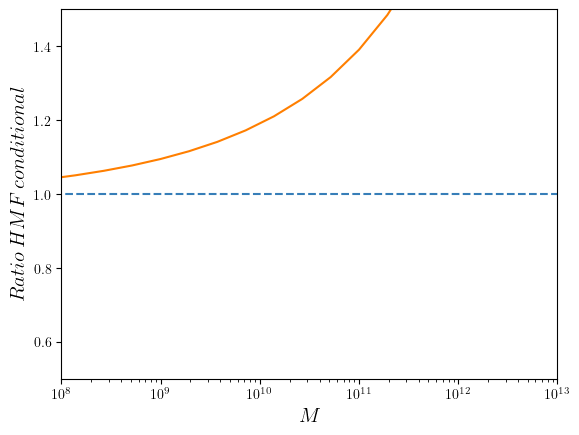

In [25]:
fig, ax = plt.subplots(1,1,)

ax.semilogx(use_M,np.ones(len(use_M)),ls='--')
ax.semilogx(use_M, ng / gauss )

ax.set_ylim(0.5,1.5)
ax.set_xlim(1e8,1e13)

ax.set_ylabel(r'$Ratio\,HMF\,conditional$',fontsize=15)
ax.set_xlabel(r'$M$',fontsize=15)
